In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
mkdir /content/layoutdm_rico_tokens

mkdir: cannot create directory ‘/content/layoutdm_rico_tokens’: File exists


In [3]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/vocab_meta.json /content/layoutdm_rico_tokens


In [4]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/tokens_train.pt /content/layoutdm_rico_tokens

In [5]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/tokens_val.pt /content/layoutdm_rico_tokens

In [6]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/tokens_test.pt /content/layoutdm_rico_tokens

In [7]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/cat2id.json /content/layoutdm_rico_tokens

In [8]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/centroids_x.pt /content/layoutdm_rico_tokens

In [9]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/centroids_y.pt /content/layoutdm_rico_tokens

In [10]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/centroids_w.pt /content/layoutdm_rico_tokens

In [11]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/centroids_h.pt /content/layoutdm_rico_tokens

In [12]:
# ==============================
# LayoutDM minimal - Colab script
# ==============================
# Paste this into a single Colab cell (or split as you like).
# It is written for correctness & clarity, not speed.

import math
import os
import json
from dataclasses import dataclass
from typing import Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ------------------------------
# 0) Config
# ------------------------------
@dataclass
class TrainConfig:
    # Diffusion
    T: int = 100                  # paper uses T=100
    lambda_aux: float = 0.1       # paper Eq.(4): λ=0.1

    # Optim (paper)
    lr: float = 5e-4
    beta1: float = 0.9
    beta2: float = 0.98
    weight_decay: float = 0.01

    # Transformer backbone (paper)
    n_layers: int = 4
    n_heads: int = 8
    d_model: int = 512
    d_ff: int = 2048
    dropout: float = 0.1

    # Layout shape
    M: int = 25                   # must match your tokenization pipeline
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


# ------------------------------
# 1) Dataset (tokens already discrete)
# ------------------------------
class LayoutTokenDataset(Dataset):
    """
    Each item:
      tokens:   LongTensor [M, 5]  (c,x,y,w,h) already discrete + padded
      pad_mask: BoolTensor [M, 5]  True where token == PAD for each modality

    Compatible with preprocesamiento_iter3, where:
      - category: pad_id = C + 1
      - x/y/w/h : pad_id = BINS + 1
    """
    MODALITIES = ["c", "x", "y", "w", "h"]

    def __init__(
        self,
        token_tensors: torch.LongTensor,
        vocab_meta: Dict[str, Dict[str, int]],
        shuffle_elements: bool = False,
    ):
        if not isinstance(token_tensors, torch.Tensor):
            raise TypeError("token_tensors must be a torch.Tensor")
        if token_tensors.ndim != 3 or token_tensors.size(-1) != 5:
            raise ValueError(f"Expected [N, M, 5], got {tuple(token_tensors.shape)}")

        self.x = token_tensors.long()
        self.vocab_meta = vocab_meta
        self.shuffle_elements = shuffle_elements

        self.pad_ids = torch.tensor(
            [vocab_meta[m]["pad_id"] for m in self.MODALITIES],
            dtype=torch.long
        )  # [5]

    def __len__(self):
        return self.x.size(0)

    def _build_pad_mask(self, tokens: torch.LongTensor) -> torch.BoolTensor:
        # tokens: [M, 5]
        # pad_ids: [5] -> broadcast to [M, 5]
        return tokens.eq(self.pad_ids)

    def _shuffle_valid_elements(self, tokens: torch.LongTensor) -> torch.LongTensor:
        """
        Shuffle only real elements, keep PAD tail at the end.
        We detect valid elements from category != c.pad_id.
        """
        c_pad = self.vocab_meta["c"]["pad_id"]
        valid = (tokens[:, 0] != c_pad)
        n_valid = int(valid.sum().item())

        if n_valid <= 1:
            return tokens

        perm = torch.randperm(n_valid)
        shuffled = tokens.clone()
        shuffled[:n_valid] = shuffled[:n_valid][perm]
        return shuffled

    def __getitem__(self, idx):
        tokens = self.x[idx].clone()

        if self.shuffle_elements:
            tokens = self._shuffle_valid_elements(tokens)

        pad_mask = self._build_pad_mask(tokens)
        return tokens, pad_mask


def load_real_dataset(
    data_dir: str,
    split: str,
) -> torch.LongTensor:
    path = os.path.join(data_dir, f"tokens_{split}.pt")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing token file: {path}")

    tokens = torch.load(path, map_location="cpu")

    if not isinstance(tokens, torch.Tensor):
        raise TypeError(f"{path} did not load as torch.Tensor")
    if tokens.ndim != 3 or tokens.size(-1) != 5:
        raise ValueError(f"{path} must have shape [N, M, 5], got {tuple(tokens.shape)}")

    return tokens.long()


def load_vocab_meta(data_dir: str) -> Dict[str, Dict[str, int]]:
    path = os.path.join(data_dir, "vocab_meta.json")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing vocab meta file: {path}")

    with open(path, "r", encoding="utf-8") as f:
        vocab_meta = json.load(f)

    required_modalities = ["c", "x", "y", "w", "h"]
    for m in required_modalities:
        if m not in vocab_meta:
            raise KeyError(f"vocab_meta missing modality: {m}")
        for k in ["vocab_size", "mask_id", "pad_id"]:
            if k not in vocab_meta[m]:
                raise KeyError(f"vocab_meta[{m}] missing key: {k}")

    if "M" not in vocab_meta:
        raise KeyError("vocab_meta missing global key: 'M'")

    return vocab_meta


def load_real_datasets(
    cfg: TrainConfig,
    data_dir: str,
    shuffle_train_elements: bool = True,
) -> Tuple[Dataset, Dataset, Dict[str, Dict[str, int]]]:
    """
    Loads:
      - tokens_train.pt
      - tokens_val.pt
      - vocab_meta.json

    Produced by preprocesamiento_iter3.
    """
    vocab_meta = load_vocab_meta(data_dir)

    train_tokens = load_real_dataset(data_dir, "train")
    val_tokens = load_real_dataset(data_dir, "val")

    data_M = int(vocab_meta["M"])
    if train_tokens.size(1) != data_M:
        raise ValueError(
            f"train_tokens M mismatch: tensor has {train_tokens.size(1)} but vocab_meta['M']={data_M}"
        )
    if val_tokens.size(1) != data_M:
        raise ValueError(
            f"val_tokens M mismatch: tensor has {val_tokens.size(1)} but vocab_meta['M']={data_M}"
        )

    # overwrite cfg.M from real artifacts
    cfg.M = data_M

    train_ds = LayoutTokenDataset(
        train_tokens,
        vocab_meta=vocab_meta,
        shuffle_elements=shuffle_train_elements,
    )
    val_ds = LayoutTokenDataset(
        val_tokens,
        vocab_meta=vocab_meta,
        shuffle_elements=False,
    )

    return train_ds, val_ds, vocab_meta


# ------------------------------
# 2) Diffusion: transition params and Qt
# ------------------------------
def make_transition_params(t: int, T: int) -> Tuple[float, float, float]:
    """
    Returns (alpha_t, beta_t, gamma_t).
    IMPORTANT: To replicate the paper strictly, replace this schedule
    with the exact schedule from the paper.
    """
    # Placeholder schedule (works, but not guaranteed paper-exact):
    s = (t / T)
    gamma_t = math.sin(s * math.pi / 2) ** 2      # 0..1 increasing
    beta_t = 0.01 * (1.0 - gamma_t)               # small
    alpha_t = 1.0 - gamma_t                       # base (we'll renormalize rows)
    return alpha_t, beta_t, gamma_t


def build_Qt(V: int, alpha_t: float, beta_t: float, gamma_t: float,
             mask_id: int, device: torch.device) -> torch.Tensor:
    """
    Build Qt [V,V] for D3PM-style masking diffusion.

    For normal tokens i != mask:
      - stay on i: alpha + beta
      - replace to any other normal token: beta
      - go to MASK: gamma
      Row is renormalized.

    MASK is absorbing:
      Qt[mask, mask] = 1
    """
    Qt = torch.zeros((V, V), device=device, dtype=torch.float32)

    normal_ids = [i for i in range(V) if i != mask_id]

    for i in normal_ids:
        Qt[i, i] = alpha_t + beta_t
        for j in normal_ids:
            if j != i:
                Qt[i, j] = beta_t
        Qt[i, mask_id] = gamma_t

        Qt[i] = Qt[i] / (Qt[i].sum() + 1e-12)

    Qt[mask_id, :] = 0.0
    Qt[mask_id, mask_id] = 1.0
    return Qt


@torch.no_grad()
def categorical_sample(probs: torch.Tensor) -> torch.Tensor:
    """
    probs: [..., V] categorical distributions
    returns: [...] int64 sample
    """
    flat = probs.reshape(-1, probs.size(-1))
    out = torch.multinomial(flat, num_samples=1).squeeze(-1)
    return out.view(probs.shape[:-1])


def q_sample_from_Qbar(z0: torch.Tensor, Qbar_t: torch.Tensor) -> torch.Tensor:
    """
    z0: [B, L] tokens
    Qbar_t: [V, V]
    sample zt ~ q(zt|z0)
    """
    probs = Qbar_t[z0]  # [B, L, V]
    return categorical_sample(probs)


def q_posterior_true(z0: torch.Tensor, zt: torch.Tensor,
                     Qt: torch.Tensor, Qbar_t_1: torch.Tensor) -> torch.Tensor:
    """
    True posterior:
      q(z_{t-1} | z_t, z0) ∝ q(z_t | z_{t-1}) * q(z_{t-1} | z0)

    Returns [B, L, V]
    """
    probs_t1_given_z0 = Qbar_t_1[z0]  # [B, L, V]
    Qt_col = Qt[:, zt].permute(1, 2, 0).contiguous()  # [B, L, V]
    unnorm = Qt_col * probs_t1_given_z0
    return unnorm / (unnorm.sum(dim=-1, keepdim=True) + 1e-12)


# ------------------------------
# 3) Model: Transformer encoder denoiser
# ------------------------------
class LayoutDMDenoiser(nn.Module):
    def __init__(self, cfg: TrainConfig, vocab_sizes: Dict[str, int]):
        super().__init__()
        self.cfg = cfg
        self.modalities = ["c", "x", "y", "w", "h"]

        self.emb = nn.ModuleDict({
            m: nn.Embedding(vocab_sizes[m], cfg.d_model) for m in self.modalities
        })

        # Decoupled positional embeddings:
        self.elem_pos = nn.Embedding(cfg.M, cfg.d_model)  # element index 0..M-1
        self.attr_pos = nn.Embedding(5, cfg.d_model)      # attribute index 0..4

        enc_layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model,
            nhead=cfg.n_heads,
            dim_feedforward=cfg.d_ff,
            dropout=cfg.dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.n_layers)

        self.head = nn.ModuleDict({
            m: nn.Linear(cfg.d_model, vocab_sizes[m]) for m in self.modalities
        })

    def forward(self, zt: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        zt: [B, M, 5]
        Return logits per modality: m -> [B, M, V_m]
        """
        B, M, A = zt.shape
        assert M == self.cfg.M and A == 5

        device = zt.device

        # [B, M]
        elem_ids = torch.arange(M, device=device).unsqueeze(0).expand(B, M)

        reps = []
        for a, m in enumerate(self.modalities):
            tok = zt[:, :, a]  # [B, M]

            # token embedding
            e = self.emb[m](tok)  # [B, M, D]

            # decoupled positional encoding:
            # - element index: 0..M-1
            # - attribute index: 0..4
            attr_ids = torch.full((B, M), a, device=device, dtype=torch.long)

            e = e + self.elem_pos(elem_ids) + self.attr_pos(attr_ids)  # [B, M, D]
            reps.append(e)

        # reps = [c_all, x_all, y_all, w_all, h_all], each [B, M, D]

        # -------------------------------------------------------
        # FIX: interleaved flatten by element, not by modality
        # -------------------------------------------------------
        c_all, x_all, y_all, w_all, h_all = reps

        mods = torch.stack([c_all, x_all, y_all, w_all, h_all], dim=2)  # [B, M, 5, D]
        seq = mods.reshape(B, M * 5, self.cfg.d_model)                   # [B, 5M, D]

        # Transformer
        h = self.encoder(seq)                                            # [B, 5M, D]

        # -------------------------------------------------------
        # Unflatten back to [B, M, 5, D]
        # -------------------------------------------------------
        h = h.reshape(B, M, 5, self.cfg.d_model)                         # [B, M, 5, D]

        h_c = h[:, :, 0, :]   # [B, M, D]
        h_x = h[:, :, 1, :]
        h_y = h[:, :, 2, :]
        h_w = h[:, :, 3, :]
        h_h = h[:, :, 4, :]

        out = {
            "c": self.head["c"](h_c),   # [B, M, Vc]
            "x": self.head["x"](h_x),   # [B, M, Vx]
            "y": self.head["y"](h_y),   # [B, M, Vy]
            "w": self.head["w"](h_w),   # [B, M, Vw]
            "h": self.head["h"](h_h),   # [B, M, Vh]
        }
        return out


# ------------------------------
# 4) Losses: VB (KL) + aux (CE on z0)
# ------------------------------
def kl_categorical(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    return (p * (torch.log(p + 1e-12) - torch.log(q + 1e-12))).sum(dim=-1)


def compute_losses(
    cfg: TrainConfig,
    logits: Dict[str, torch.Tensor],  # m -> [B,M,V]
    z0: torch.Tensor,                 # [B,M,5]
    zt: torch.Tensor,                 # [B,M,5]
    t: int,
    Qts_t: Dict[str, torch.Tensor],          # m -> Qt [V,V]
    Qbars_prev: Dict[str, torch.Tensor],     # m -> Qbar_{t-1} [V,V]
    pad_mask: torch.Tensor,                  # [B,M,5] bool
) -> Tuple[torch.Tensor, Dict[str, float]]:
    modalities = ["c", "x", "y", "w", "h"]
    vb_terms, aux_terms = [], []

    B, M, _ = z0.shape

    for a, m in enumerate(modalities):
        V = logits[m].size(-1)
        z0_m = z0[:, :, a]              # [B,M]
        zt_m = zt[:, :, a]              # [B,M]

        valid = (~pad_mask[:, :, a]).float()  # [B,M]
        denom = valid.sum().clamp_min(1.0)

        # true posterior q(z_{t-1} | z_t, z0)
        q_true = q_posterior_true(z0_m, zt_m, Qts_t[m], Qbars_prev[m])  # [B,M,V]

        # model posterior p_theta(z_{t-1} | z_t)
        p_model = F.softmax(logits[m], dim=-1)

        # VB
        kl = kl_categorical(q_true, p_model)          # [B,M]
        vb = (kl * valid).sum() / denom
        vb_terms.append(vb)

        # Aux: CE to reconstruct z0
        ce = F.cross_entropy(logits[m].reshape(-1, V), z0_m.reshape(-1), reduction="none").reshape(B, M)
        aux = (ce * valid).sum() / denom
        aux_terms.append(aux)

    vb_loss = torch.stack(vb_terms).mean()
    aux_loss = torch.stack(aux_terms).mean()
    total = vb_loss + cfg.lambda_aux * aux_loss

    return total, {
        "loss_total": float(total.detach().cpu()),
        "loss_vb": float(vb_loss.detach().cpu()),
        "loss_aux": float(aux_loss.detach().cpu()),
    }


# ------------------------------
# 5) Training loop (minimal, clear)
# ------------------------------
def precompute_Q_mats(cfg, vocab_meta, device):
    Qts_all = {}
    Qbars_all = {}

    modalities = ["c", "x", "y", "w", "h"]

    for m in modalities:
        meta = vocab_meta[m]
        V = meta["vocab_size"]
        mask_id = meta["mask_id"]

        Qts = []
        Qbars = []

        Qbar = torch.eye(V, device=device)
        for t in range(1, cfg.T + 1):
            alpha_t, beta_t, gamma_t = make_transition_params(t, cfg.T)
            Qt = build_Qt(
                V=V,
                alpha_t=alpha_t,
                beta_t=beta_t,
                gamma_t=gamma_t,
                mask_id=mask_id,
                device=device,
            )
            Qbar = Qt @ Qbar
            Qts.append(Qt)
            Qbars.append(Qbar.clone())

        Qts_all[m] = Qts
        Qbars_all[m] = Qbars

    return Qts_all, Qbars_all


def train_one_epoch(cfg: TrainConfig, model: nn.Module, loader: DataLoader,
                    opt: torch.optim.Optimizer, Qts_all, Qbars_all,
                    vocab_meta: Dict[str, Dict[str, int]]):
    model.train()
    device = torch.device(cfg.device)

    step = 0
    for tokens, pad_mask in loader:
        tokens = tokens.to(device)        # [B,M,5]
        pad_mask = pad_mask.to(device)    # [B,M,5]
        B = tokens.size(0)

        # sample a single timestep for the batch (common diffusion practice)
        t = torch.randint(1, cfg.T + 1, (1,), device=device).item()

        if not (1 <= t <= cfg.T):
            raise ValueError(f"Sampled invalid timestep t={t}, expected 1..{cfg.T}")

        modalities = ["c", "x", "y", "w", "h"]

        # build zt by modality from Qbar_t
        zt = tokens.clone()
        Qts_t = {}
        Qbars_prev = {}

        for a, m in enumerate(modalities):
            # q(x_t | x_0)
            Qbar_t = Qbars_all[m][t - 1]
            zt[:, :, a] = q_sample_from_Qbar(tokens[:, :, a], Qbar_t)

            # Qts_t[m] = Qts_all[m][t]
            # Qbars_prev[m] = Qbars_all[m][t - 1]
            Qts_t[m] = Qts_all[m][t - 1]

            # q(x_{t-1} | x_0)
            if t == 1:
                V = vocab_meta[m]["vocab_size"]
                Qbars_prev[m] = torch.eye(V, device=cfg.device)
            else:
                Qbars_prev[m] = Qbars_all[m][t - 2]

        logits = model(zt)

        loss, metrics = compute_losses(cfg, logits, tokens, zt, t, Qts_t, Qbars_prev, pad_mask)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        step += 1
        if step % 50 == 0:
            print(f"step={step:04d} t={t:03d} "
                  f"loss={metrics['loss_total']:.4f} vb={metrics['loss_vb']:.4f} aux={metrics['loss_aux']:.4f}")


# ------------------------------
# 6) Unconditional sampling (reverse diffusion)
# ------------------------------
@torch.no_grad()
def unconditional_sample(model: nn.Module, cfg: TrainConfig,
                         vocab_meta: Dict[str, Dict[str, int]],
                         batch_size: int = 4) -> torch.LongTensor:
    """
    z_T: all [MASK] for all modalities
    for t=T..1:
      logits = model(z_t) -> p(z_{t-1}|z_t)
      sample categorical -> z_{t-1}
    """
    model.eval()
    device = torch.device(cfg.device)

    modalities = ["c", "x", "y", "w", "h"]
    mask_ids = {m: vocab_meta[m]["mask_id"] for m in modalities}
    pad_ids  = {m: vocab_meta[m]["pad_id"]  for m in modalities}

    B, M = batch_size, cfg.M

    # init z_T
    zt = torch.zeros((B, M, 5), dtype=torch.long, device=device)
    for a, m in enumerate(modalities):
        zt[:, :, a] = mask_ids[m]

    for t in range(cfg.T, 0, -1):
        logits = model(zt)  # m -> [B,M,V]
        z_prev = zt.clone()

        for a, m in enumerate(modalities):
            probs = F.softmax(logits[m], dim=-1)  # [B,M,V]
            flat = probs.reshape(-1, probs.size(-1))
            sampled = torch.multinomial(flat, 1).squeeze(-1).view(B, M)
            z_prev[:, :, a] = sampled

        # coherence rule for PAD:
        # if category is PAD in a slot, force x,y,w,h to PAD too
        c_pad = (z_prev[:, :, 0] == pad_ids["c"])
        if c_pad.any():
            z_prev[:, :, 1] = torch.where(c_pad, torch.full_like(z_prev[:, :, 1], pad_ids["x"]), z_prev[:, :, 1])
            z_prev[:, :, 2] = torch.where(c_pad, torch.full_like(z_prev[:, :, 2], pad_ids["y"]), z_prev[:, :, 2])
            z_prev[:, :, 3] = torch.where(c_pad, torch.full_like(z_prev[:, :, 3], pad_ids["w"]), z_prev[:, :, 3])
            z_prev[:, :, 4] = torch.where(c_pad, torch.full_like(z_prev[:, :, 4], pad_ids["h"]), z_prev[:, :, 4])

        zt = z_prev

    return zt  # z_0


# ------------------------------
# 7) Main: wire everything
# ------------------------------
def main(
    data_dir: str = "/content/layoutdm_rico_tokens",
    batch_size: int = 16,
    epochs: int = 1,
    shuffle_train_elements: bool = True,
):
    cfg = TrainConfig()
    print("Device:", cfg.device)
    print("Loading real artifacts from:", data_dir)

    # Data + vocab meta from preprocesamiento_iter3 artifacts
    train_ds, val_ds, vocab_meta = load_real_datasets(
        cfg=cfg,
        data_dir=data_dir,
        shuffle_train_elements=shuffle_train_elements,
    )

    print("Loaded M from vocab_meta:", cfg.M)
    print("Train samples:", len(train_ds))
    print("Val samples:", len(val_ds))

    vocab_sizes = {m: meta["vocab_size"] for m, meta in vocab_meta.items() if m in ["c", "x", "y", "w", "h"]}

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # Model
    model = LayoutDMDenoiser(cfg, vocab_sizes).to(cfg.device)
    opt = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        betas=(cfg.beta1, cfg.beta2),
        weight_decay=cfg.weight_decay,
    )

    # Precompute diffusion matrices
    device = torch.device(cfg.device)
    Qts_all, Qbars_all = precompute_Q_mats(cfg, vocab_meta, device)

    # Train
    for ep in range(epochs):
        print(f"\n=== Epoch {ep+1}/{epochs} ===")
        train_one_epoch(cfg, model, train_loader, opt, Qts_all, Qbars_all, vocab_meta)

    # Save checkpoint
    ckpt_path = os.path.join(data_dir, "layoutdm_rico_real.pt")
    torch.save({
        "cfg": cfg.__dict__,
        "model_state": model.state_dict(),
        "vocab_meta": vocab_meta,
    }, ckpt_path)
    print("Saved:", ckpt_path)

    # Unconditional sampling demo
    samples = unconditional_sample(model, cfg, vocab_meta, batch_size=4)
    print("Sample tokens shape:", samples.shape)  # [B,M,5]
    print("First sample (first 5 elements):\n", samples[0, :5, :])
    return model, cfg, train_ds, val_ds, vocab_meta




In [13]:

# if __name__ == "__main__":
#     main()
model, cfg, train_ds, val_ds, vocab_meta = main(epochs=3)


Device: cuda
Loading real artifacts from: /content/layoutdm_rico_tokens
Loaded M from vocab_meta: 25
Train samples: 52954
Val samples: 6619


/tmp/ipykernel_3211/1364139687.py:311: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.n_layers)



=== Epoch 1/3 ===
step=0050 t=092 loss=0.6889 vb=0.1423 aux=5.4655
step=0100 t=063 loss=0.6795 vb=0.0938 aux=5.8566
step=0150 t=090 loss=0.6791 vb=0.1040 aux=5.7517
step=0200 t=005 loss=0.5839 vb=0.1993 aux=3.8465
step=0250 t=016 loss=0.5458 vb=0.0782 aux=4.6766
step=0300 t=035 loss=0.6249 vb=0.0512 aux=5.7367
step=0350 t=060 loss=0.6745 vb=0.1106 aux=5.6397
step=0400 t=053 loss=0.6603 vb=0.0900 aux=5.7032
step=0450 t=081 loss=0.6818 vb=0.0868 aux=5.9497
step=0500 t=039 loss=0.6275 vb=0.0768 aux=5.5067
step=0550 t=077 loss=0.6781 vb=0.1026 aux=5.7543
step=0600 t=083 loss=0.6716 vb=0.0823 aux=5.8937
step=0650 t=040 loss=0.6454 vb=0.0908 aux=5.5467
step=0700 t=100 loss=0.6565 vb=0.0926 aux=5.6391
step=0750 t=089 loss=0.6763 vb=0.1359 aux=5.4043
step=0800 t=065 loss=0.6702 vb=0.0843 aux=5.8592
step=0850 t=026 loss=0.5817 vb=0.0711 aux=5.1058
step=0900 t=012 loss=0.5113 vb=0.0587 aux=4.5267
step=0950 t=049 loss=0.6763 vb=0.0918 aux=5.8451
step=1000 t=036 loss=0.6267 vb=0.0828 aux=5.4398
s

In [14]:
import os
import json
import torch

data_dir = "/content/layoutdm_rico_tokens"

with open(os.path.join(data_dir, "vocab_meta.json"), "r", encoding="utf-8") as f:
    vocab_meta = json.load(f)

with open(os.path.join(data_dir, "cat2id.json"), "r", encoding="utf-8") as f:
    cat2id = json.load(f)

id2cat = {v: k for k, v in cat2id.items()}

centroids = {
    "x": torch.load(os.path.join(data_dir, "centroids_x.pt")),
    "y": torch.load(os.path.join(data_dir, "centroids_y.pt")),
    "w": torch.load(os.path.join(data_dir, "centroids_w.pt")),
    "h": torch.load(os.path.join(data_dir, "centroids_h.pt")),
}

def decode_layout(tokens, vocab_meta, id2cat, centroids):
    """
    tokens: [M, 5]  -> (c,x,y,w,h)
    retorna lista de elementos reales
    """
    out = []

    c_pad = vocab_meta["c"]["pad_id"]
    c_mask = vocab_meta["c"]["mask_id"]

    x_pad = vocab_meta["x"]["pad_id"]
    y_pad = vocab_meta["y"]["pad_id"]
    w_pad = vocab_meta["w"]["pad_id"]
    h_pad = vocab_meta["h"]["pad_id"]

    for row in tokens.tolist():
        c_id, x_id, y_id, w_id, h_id = row

        # ignorar PAD
        if c_id == c_pad:
            continue

        # ignorar MASK o ids fuera de rango
        if c_id == c_mask:
            continue
        if c_id not in id2cat:
            continue

        if x_id >= len(centroids["x"]) or y_id >= len(centroids["y"]) or w_id >= len(centroids["w"]) or h_id >= len(centroids["h"]):
            continue

        elem = {
            "class": id2cat[c_id],
            "x": float(centroids["x"][x_id]),
            "y": float(centroids["y"][y_id]),
            "w": float(centroids["w"][w_id]),
            "h": float(centroids["h"][h_id]),
        }
        out.append(elem)

    return out

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def render_layout(decoded, canvas_w=360, canvas_h=640, title="Generated Layout"):
    fig, ax = plt.subplots(figsize=(4, 7))
    ax.set_xlim(0, canvas_w)
    ax.set_ylim(canvas_h, 0)
    ax.set_title(title)

    for elem in decoded:
        x = elem["x"] * canvas_w
        y = elem["y"] * canvas_h
        w = elem["w"] * canvas_w
        h = elem["h"] * canvas_h

        x0 = x - w / 2
        y0 = y - h / 2

        rect = patches.Rectangle((x0, y0), w, h, fill=False)
        ax.add_patch(rect)
        ax.text(x0, y0, elem["class"], fontsize=6)

    plt.show()

In [20]:
samples = unconditional_sample(model, cfg, vocab_meta, batch_size=8)

for i in range(samples.size(0)):
    decoded = decode_layout(samples[i].cpu(), vocab_meta, id2cat, centroids)
    print(f"Sample {i}: {len(decoded)} elementos")
    render_layout(decoded, title=f"Sample {i}")

Sample 0: 25 elementos


TypeError: render_layout() missing 1 required positional argument: 'decoded'

tokens_val shape: (6619, 25, 5)
Selected indices: [5238, 912, 204, 6074, 2253, 2006, 1828, 1143, 6033, 839, 5543, 6067, 4467, 712, 4837, 3456, 260, 244, 767, 1791]


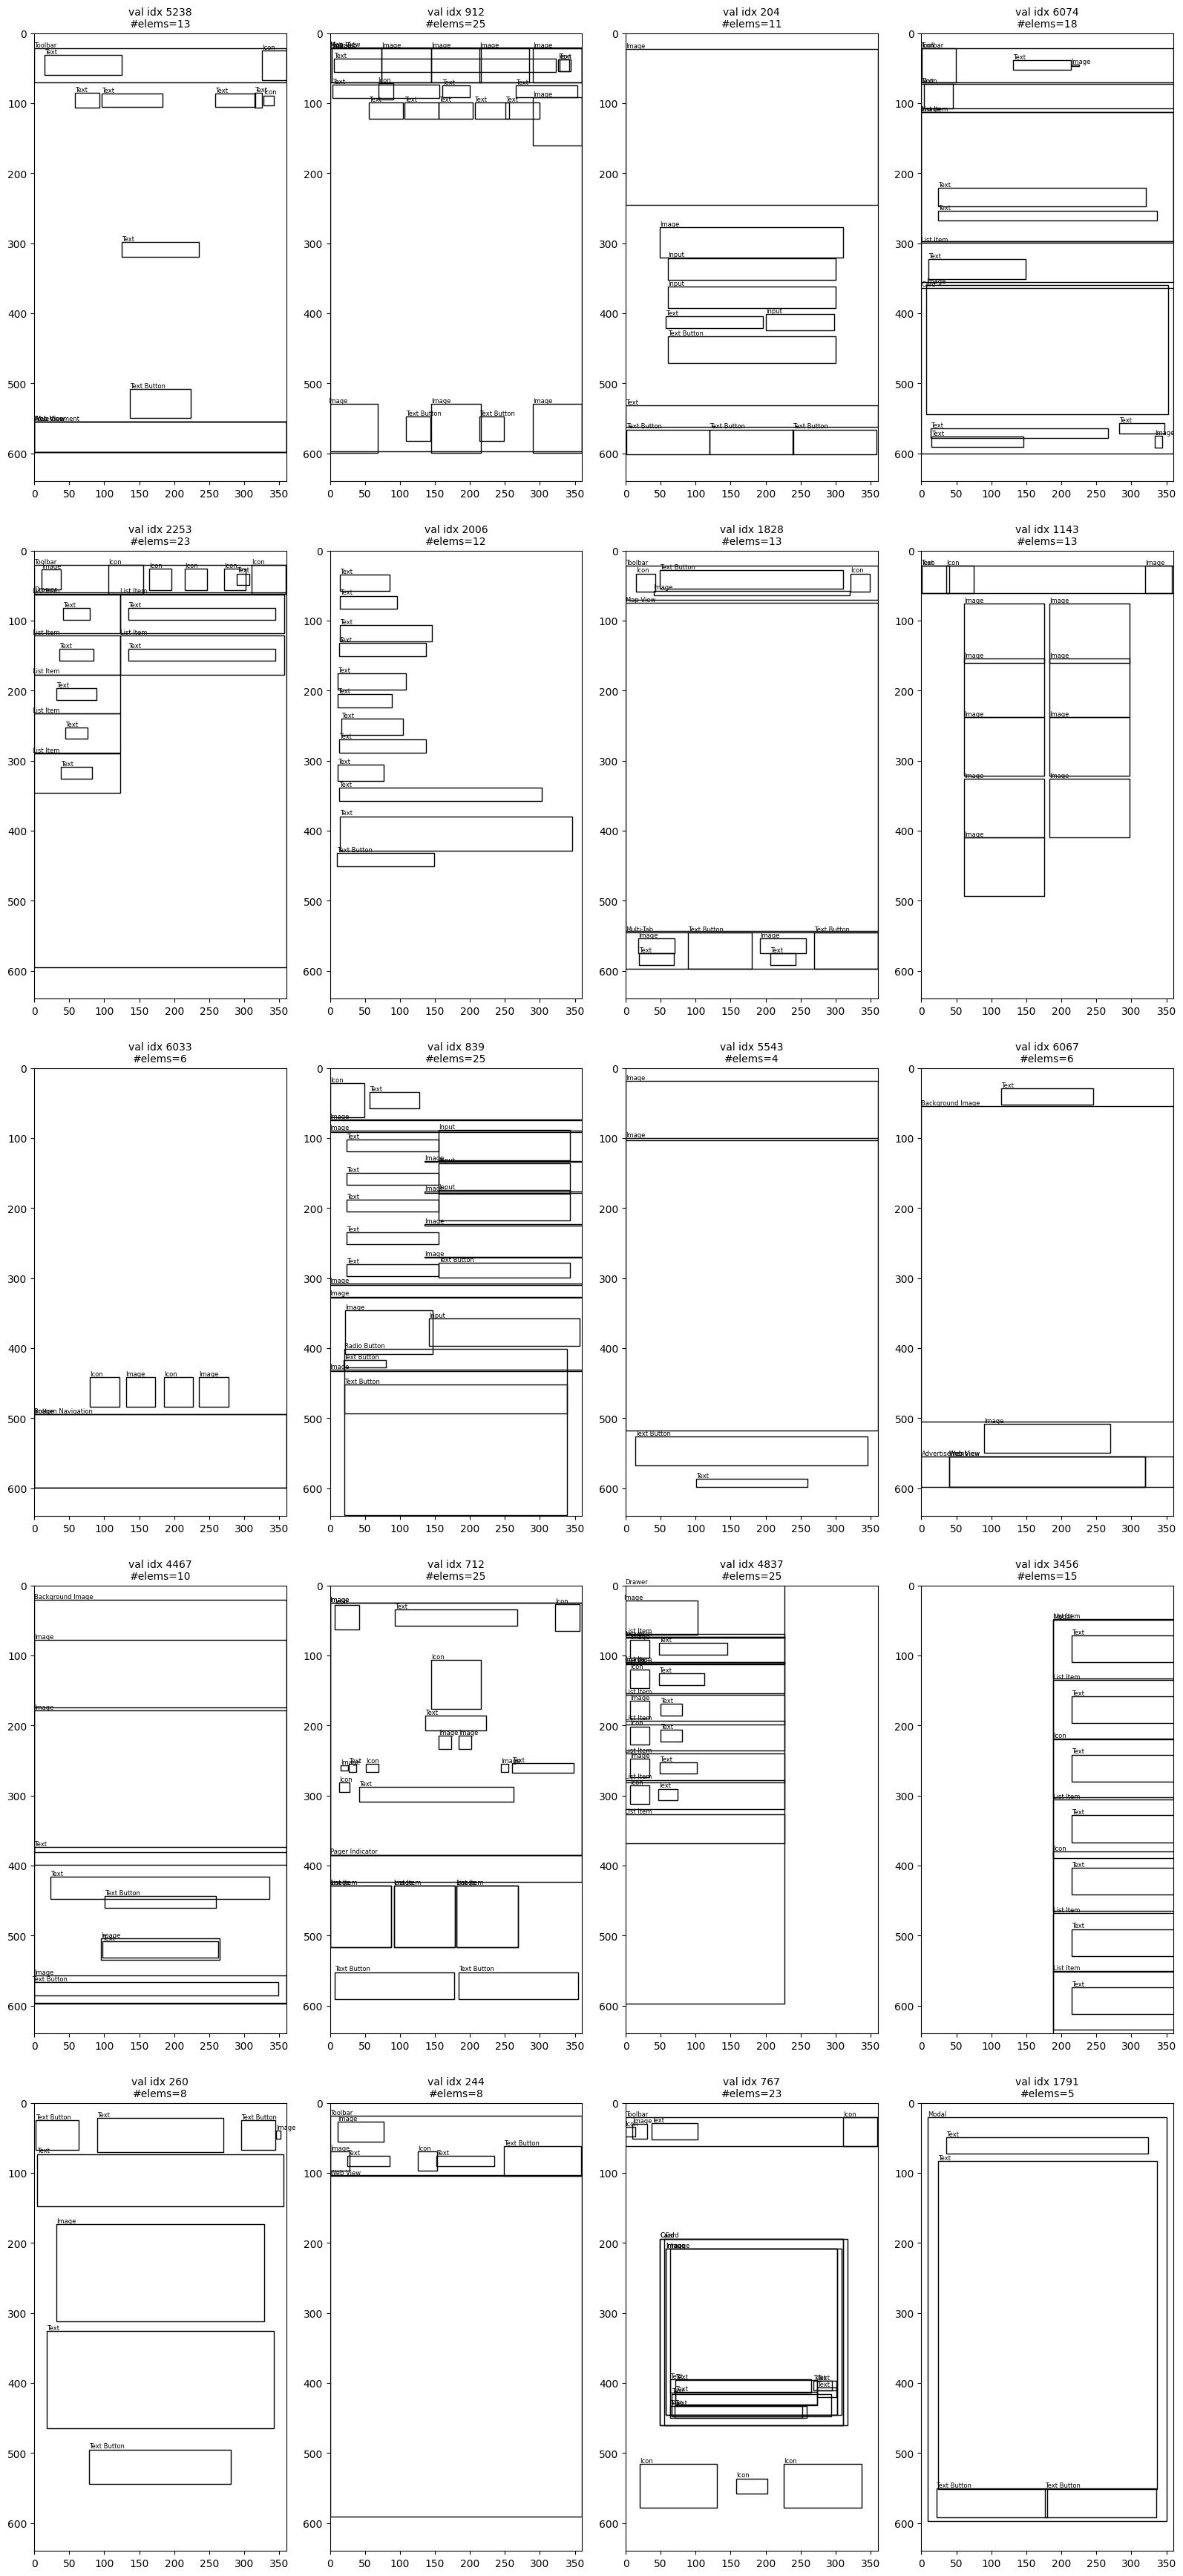

In [17]:
import os
import json
import math
import random
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================
# Config
# =========================================================
DATA_DIR = "/content/layoutdm_rico_tokens"
TOKENS_FILE = os.path.join(DATA_DIR, "tokens_val.pt")

CANVAS_W = 360
CANVAS_H = 640

NUM_SAMPLES = 20
RANDOM_SEED = 42
USE_RANDOM_SAMPLES = True   # True = aleatorias, False = primeras 20

# =========================================================
# Load artifacts
# =========================================================
with open(os.path.join(DATA_DIR, "vocab_meta.json"), "r", encoding="utf-8") as f:
    vocab_meta = json.load(f)

with open(os.path.join(DATA_DIR, "cat2id.json"), "r", encoding="utf-8") as f:
    cat2id = json.load(f)

id2cat = {int(v): k for k, v in cat2id.items()}

centroids = {
    "x": torch.load(os.path.join(DATA_DIR, "centroids_x.pt"), map_location="cpu"),
    "y": torch.load(os.path.join(DATA_DIR, "centroids_y.pt"), map_location="cpu"),
    "w": torch.load(os.path.join(DATA_DIR, "centroids_w.pt"), map_location="cpu"),
    "h": torch.load(os.path.join(DATA_DIR, "centroids_h.pt"), map_location="cpu"),
}

tokens_val = torch.load(TOKENS_FILE, map_location="cpu").long()

print("tokens_val shape:", tuple(tokens_val.shape))


# =========================================================
# Decode helpers
# =========================================================
def safe_centroid_lookup(centroid_tensor, idx):
    idx = int(idx)
    if idx < 0 or idx >= len(centroid_tensor):
        return None
    return float(centroid_tensor[idx])


def decode_layout(tokens_row, vocab_meta, id2cat, centroids):
    """
    tokens_row: [M, 5] => (c, x, y, w, h)
    return: list[dict]
    """
    decoded = []

    c_pad = int(vocab_meta["c"]["pad_id"])
    c_mask = int(vocab_meta["c"]["mask_id"])

    x_pad = int(vocab_meta["x"]["pad_id"])
    x_mask = int(vocab_meta["x"]["mask_id"])
    y_pad = int(vocab_meta["y"]["pad_id"])
    y_mask = int(vocab_meta["y"]["mask_id"])
    w_pad = int(vocab_meta["w"]["pad_id"])
    w_mask = int(vocab_meta["w"]["mask_id"])
    h_pad = int(vocab_meta["h"]["pad_id"])
    h_mask = int(vocab_meta["h"]["mask_id"])

    for row in tokens_row.tolist():
        c_id, x_id, y_id, w_id, h_id = [int(v) for v in row]

        # PAD row
        if c_id == c_pad:
            continue

        # skip MASK rows / invalid category
        if c_id == c_mask or c_id not in id2cat:
            continue

        # skip masked/padded geometry
        if x_id in (x_pad, x_mask) or y_id in (y_pad, y_mask) or w_id in (w_pad, w_mask) or h_id in (h_pad, h_mask):
            continue

        x = safe_centroid_lookup(centroids["x"], x_id)
        y = safe_centroid_lookup(centroids["y"], y_id)
        w = safe_centroid_lookup(centroids["w"], w_id)
        h = safe_centroid_lookup(centroids["h"], h_id)

        if None in (x, y, w, h):
            continue

        decoded.append({
            "class": id2cat[c_id],
            "x": x,
            "y": y,
            "w": w,
            "h": h,
        })

    return decoded


# =========================================================
# Render helpers
# =========================================================
def render_layout(ax, decoded, canvas_w=360, canvas_h=640, title=""):
    ax.set_xlim(0, canvas_w)
    ax.set_ylim(canvas_h, 0)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")

    for elem in decoded:
        cls = elem["class"]

        # normalized center-size -> pixel box
        x = elem["x"] * canvas_w
        y = elem["y"] * canvas_h
        w = elem["w"] * canvas_w
        h = elem["h"] * canvas_h

        # basic sanity guards
        if w <= 0 or h <= 0:
            continue

        x0 = x - w / 2
        y0 = y - h / 2

        rect = patches.Rectangle((x0, y0), w, h, fill=False, linewidth=1)
        ax.add_patch(rect)
        ax.text(x0, y0, cls, fontsize=6, va="bottom")

    ax.grid(False)


# =========================================================
# Pick 20 samples
# =========================================================
N = tokens_val.shape[0]
num = min(NUM_SAMPLES, N)

if USE_RANDOM_SAMPLES:
    random.seed(RANDOM_SEED)
    indices = random.sample(range(N), num)
else:
    indices = list(range(num))

print("Selected indices:", indices)


# =========================================================
# Render 20 samples in a grid
# =========================================================
cols = 4
rows = math.ceil(num / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 7))
axes = axes.flatten()

for i, idx in enumerate(indices):
    tokens_row = tokens_val[idx]   # [M, 5]
    decoded = decode_layout(tokens_row, vocab_meta, id2cat, centroids)
    render_layout(
        axes[i],
        decoded,
        canvas_w=CANVAS_W,
        canvas_h=CANVAS_H,
        title=f"val idx {idx}\n#elems={len(decoded)}"
    )

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()